DIABETES PROGRESSION PREDICTION

Dataset loaded successfully.
Dataset shape: (442, 10)

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Missing values:
0

Training samples: 353
Testing samples: 89

Linear Regression model trained successfully.

First 10 predictions:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]

MODEL PERFORMANCE
Mean Squared Error (MSE): 2900.1936
R² Score: 0.4526

Actual vs Predicted Values:


,Actual Progression,Predicted Progression
0,219.0,139.547558
1,70.0,179.517208
2,202.0,134.038756
3,230.0,291.417029
4,111.0,123.789659
5,84.0,92.172347
6,242.0,258.232389
7,272.0,181.337321
8,94.0,90.224113
9,96.0,108.633759



Model Coefficients:


,Feature,Coefficient
0,age,37.904021
1,sex,-241.964362
2,bmi,542.428759
3,bp,347.703844
4,s1,-931.488846
5,s2,518.062277
6,s3,163.419983
7,s4,275.317902
8,s5,736.198859
9,s6,48.670657


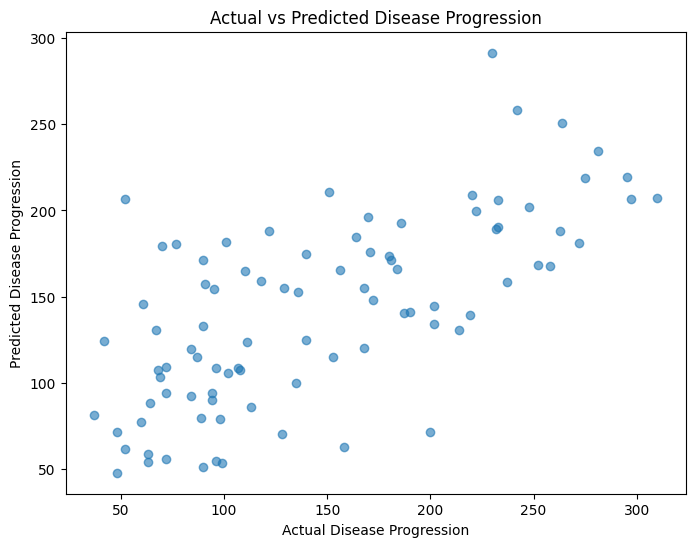


CONCLUSION

A Linear Regression model was successfully developed using
the Scikit-learn Diabetes Dataset.

The dataset was divided into training and testing sets.
The model was trained on the training data and used to
predict disease progression on the testing data.

The model was evaluated using Mean Squared Error (MSE)
and R² Score.



In [1]:
# ============================================================
# IT CLUB SUMMER INTERNSHIP 2026
# WEEK 4 - REGRESSION MODELS
# TASK 2: DIABETES PROGRESSION PREDICTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

diabetes = load_diabetes()

X = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

y = pd.Series(
    diabetes.target,
    name="DiseaseProgression"
)

print("=" * 70)
print("DIABETES PROGRESSION PREDICTION")
print("=" * 70)

print("\nDataset loaded successfully.")
print("Dataset shape:", X.shape)

print("\nFeature names:")
print(list(X.columns))

print("\nFirst 5 rows:")
display(X.head())

# ------------------------------------------------------------
# 2. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMissing values:")
print(X.isnull().sum().sum())

# ------------------------------------------------------------
# 3. SPLIT DATASET
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ------------------------------------------------------------
# 4. TRAIN LINEAR REGRESSION MODEL
# ------------------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully.")

# ------------------------------------------------------------
# 5. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model.predict(X_test)

print("\nFirst 10 predictions:")
print(y_pred[:10])

# ------------------------------------------------------------
# 6. EVALUATE MODEL
# ------------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# ------------------------------------------------------------
# 7. ACTUAL VS PREDICTED VALUES
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Actual Progression": y_test.values[:10],
    "Predicted Progression": y_pred[:10]
})

print("\nActual vs Predicted Values:")
display(comparison)

# ------------------------------------------------------------
# 8. MODEL COEFFICIENTS
# ------------------------------------------------------------

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nModel Coefficients:")
display(coefficients)

# ------------------------------------------------------------
# 9. VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Actual vs Predicted Disease Progression")

plt.show()

# ------------------------------------------------------------
# 10. CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)

print("""
A Linear Regression model was successfully developed using
the Scikit-learn Diabetes Dataset.

The dataset was divided into training and testing sets.
The model was trained on the training data and used to
predict disease progression on the testing data.

The model was evaluated using Mean Squared Error (MSE)
and R² Score.
""")